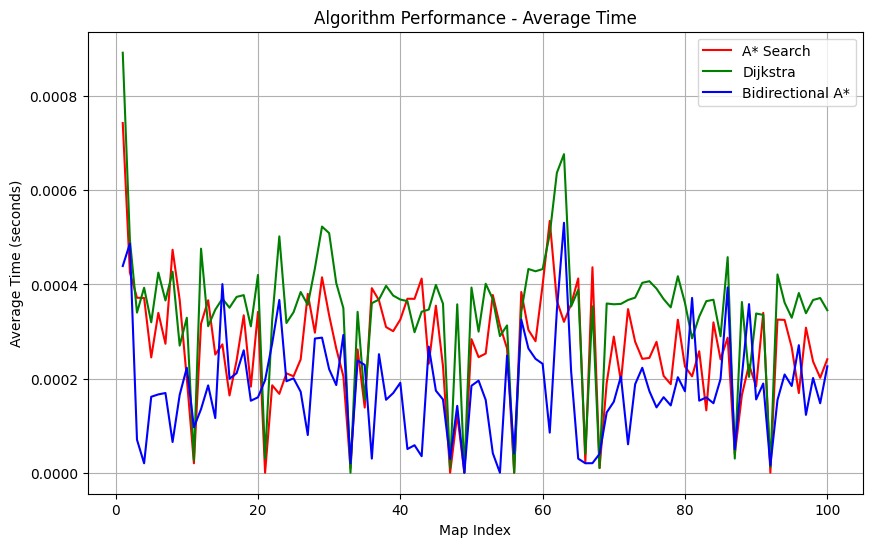

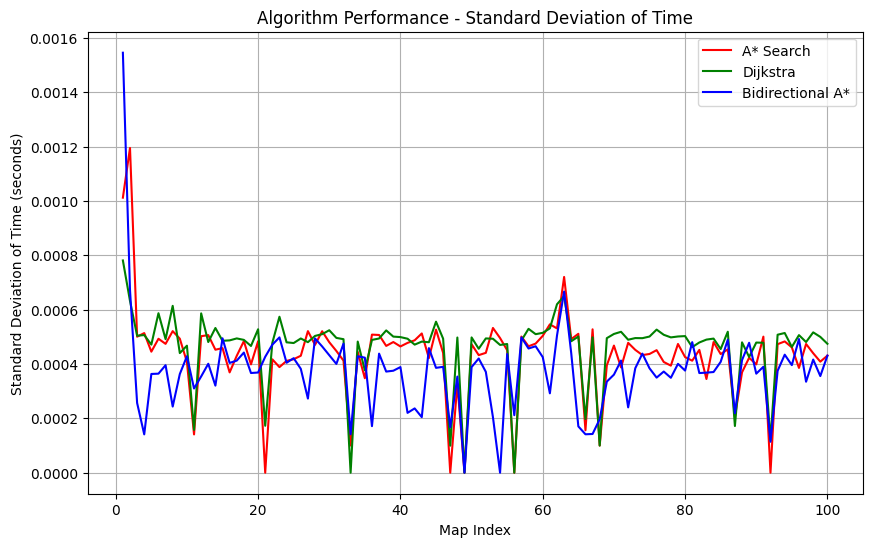

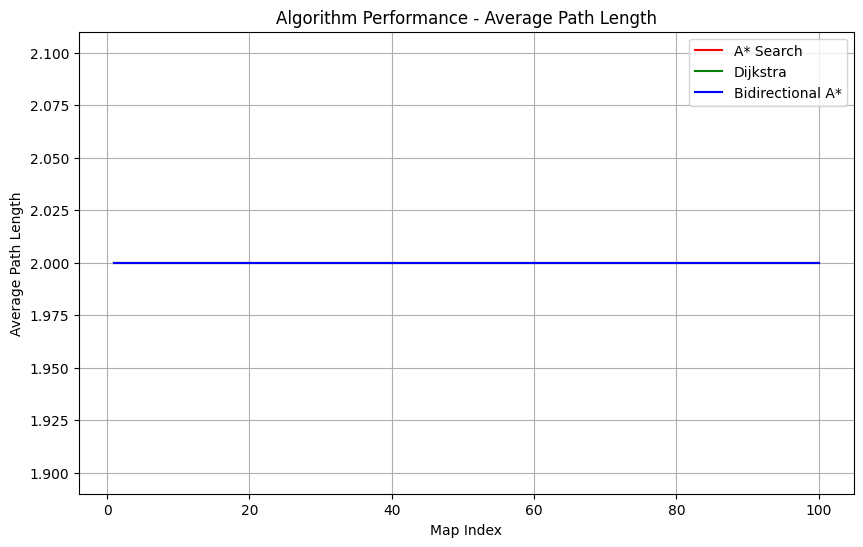

                Metric  A* Search   Dijkstra  Bidirectional A*
0     Average Time (s) 0.00026725 0.00035268        0.00018501
1   Std. Deviation (s) 0.00042444 0.00046389        0.00037377
2  Average Path Length 2.00000000 2.00000000        2.00000000


In [ ]:
import time
import random
import pandas as pd
import psutil  # For memory usage tracking
import statistics  # For standard deviation
import matplotlib.pyplot as plt  # For graph plotting
from map_graph import create_map
from a_star import a_star_search
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star 

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()

    time_taken = end_time - start_time
    path_length = len(path)

    # Memory usage for the entire process
    memory_usage = psutil.Process().memory_info().rss  
    return time_taken, path_length, memory_usage

# Function to calculate statistics (average, standard deviation, and path length)
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Function to run the comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)

    a_star_times = []
    dijkstra_times = []
    bidirectional_a_star_times = []

    a_star_lengths = []
    dijkstra_lengths = []
    bidirectional_a_star_lengths = []

    a_star_std_dev = []
    dijkstra_std_dev = []
    bidirectional_a_star_std_dev = []

    for _ in range(iterations):
        # A* Search
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        # Dijkstra's Algorithm
        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        # Bidirectional A* Search
        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    # Calculate statistics for the current map
    a_star_stats = calculate_stats(a_star_times, a_star_lengths)
    dijkstra_stats = calculate_stats(dijkstra_times, dijkstra_lengths)
    bidirectional_a_star_stats = calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)

    return a_star_stats, dijkstra_stats, bidirectional_a_star_stats

# Run comparison for 100 maps and collect stats
def run_comparison_for_multiple_maps(num_maps=100, iterations=200):
    a_star_avg_times = []
    dijkstra_avg_times = []
    bidirectional_a_star_avg_times = []

    a_star_std_devs = []
    dijkstra_std_devs = []
    bidirectional_a_star_std_devs = []

    a_star_avg_lengths = []
    dijkstra_avg_lengths = []
    bidirectional_a_star_avg_lengths = []

    for _ in range(num_maps):
        grid = create_map()  # Generate a random map
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)

        a_star_avg_times.append(a_star_stats[0])  # Average time for A*
        dijkstra_avg_times.append(dijkstra_stats[0])  # Average time for Dijkstra
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])  # Average time for Bidirectional A*

        a_star_std_devs.append(a_star_stats[1])  # Standard deviation for A*
        dijkstra_std_devs.append(dijkstra_stats[1])  # Standard deviation for Dijkstra
        bidirectional_a_star_std_devs.append(bidirectional_a_star_stats[1])  # Standard deviation for Bidirectional A*

        a_star_avg_lengths.append(a_star_stats[2])  # Average path length for A*
        dijkstra_avg_lengths.append(dijkstra_stats[2])  # Average path length for Dijkstra
        bidirectional_a_star_avg_lengths.append(bidirectional_a_star_stats[2])  # Average path length for Bidirectional A*

    return (a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

# Plotting the graph for multiple metrics
def plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths):
    
    maps = list(range(1, len(a_star_avg_times) + 1))
    
    # Average Time Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_times, label="A* Search", color='r')
    plt.plot(maps, dijkstra_avg_times, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_avg_times, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Algorithm Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Standard Deviation Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_std_devs, label="A* Search", color='r')
    plt.plot(maps, dijkstra_std_devs, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_std_devs, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Standard Deviation of Time (seconds)')
    plt.title('Algorithm Performance - Standard Deviation of Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Average Path Length Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_lengths, label="A* Search", color='r')
    plt.plot(maps, dijkstra_avg_lengths, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_avg_lengths, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Average Path Length')
    plt.title('Algorithm Performance - Average Path Length')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison for 100 maps and plot the graphs
(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
 a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
 a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths) = run_comparison_for_multiple_maps(100, 100)

plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times = []
    dijkstra_avg_times = []
    bidirectional_a_star_avg_times = []

    a_star_std_devs = []
    dijkstra_std_devs = []
    bidirectional_a_star_std_devs = []

    a_star_avg_lengths = []
    dijkstra_avg_lengths = []
    bidirectional_a_star_avg_lengths = []

    for _ in range(num_maps):
        grid = create_map()  # Generate a random map
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)

        a_star_avg_times.append(a_star_stats[0])  # Average time for A*
        dijkstra_avg_times.append(dijkstra_stats[0])  # Average time for Dijkstra
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])  # Average time for Bidirectional A*

        a_star_std_devs.append(a_star_stats[1])  # Standard deviation for A*
        dijkstra_std_devs.append(dijkstra_stats[1])  # Standard deviation for Dijkstra
        bidirectional_a_star_std_devs.append(bidirectional_a_star_stats[1])  # Standard deviation for Bidirectional A*

        a_star_avg_lengths.append(a_star_stats[2])  # Average path length for A*
        dijkstra_avg_lengths.append(dijkstra_stats[2])  # Average path length for Dijkstra
        bidirectional_a_star_avg_lengths.append(bidirectional_a_star_stats[2])  # Average path length for Bidirectional A*

    return (a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

# Create a table for results
def generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                           a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                           a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths):
    data = {
        "Metric": ["Average Time (s)", "Std. Deviation (s)", "Average Path Length"],
        "A* Search": [
            sum(a_star_avg_times) / len(a_star_avg_times),
            sum(a_star_std_devs) / len(a_star_std_devs),
            sum(a_star_avg_lengths) / len(a_star_avg_lengths)
        ],
        "Dijkstra": [
            sum(dijkstra_avg_times) / len(dijkstra_avg_times),
            sum(dijkstra_std_devs) / len(dijkstra_std_devs),
            sum(dijkstra_avg_lengths) / len(dijkstra_avg_lengths)
        ],
        "Bidirectional A*": [
            sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times),
            sum(bidirectional_a_star_std_devs) / len(bidirectional_a_star_std_devs),
            sum(bidirectional_a_star_avg_lengths) / len(bidirectional_a_star_avg_lengths)
        ]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")  # Set display format for floats
    return df

# Run the comparison
(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
 a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
 a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths) = run_comparison_for_multiple_maps(100, 100)

# Generate and display the table
results_table = generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                                       a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                                       a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

print(results_table)


             Metric  A* Search   Dijkstra  Bidirectional A*
0  Average Time (s) 0.00028207 0.00036978        0.00018780


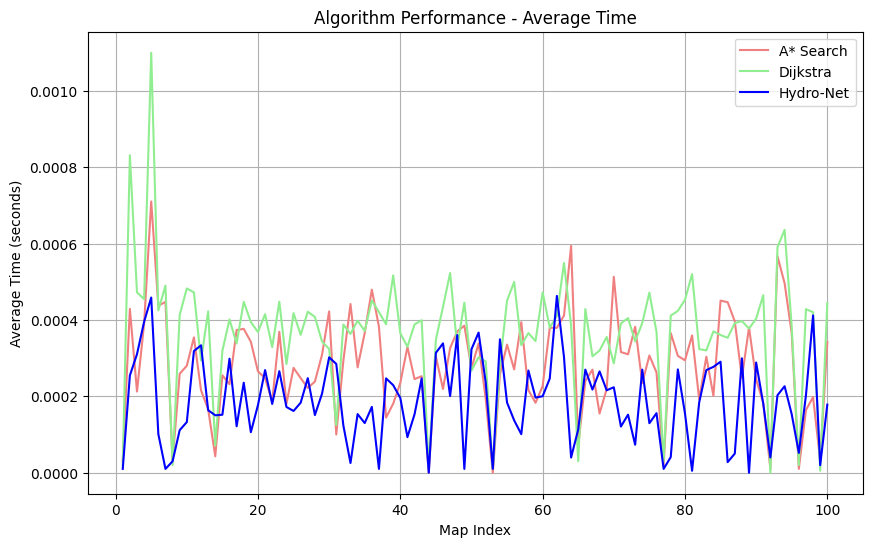

In [9]:
import time
import random
import pandas as pd
import psutil
import statistics
import matplotlib.pyplot as plt
from map_graph import create_map
from a_star import a_star_search
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    a_star_times, dijkstra_times, bidirectional_a_star_times = [], [], []
    a_star_lengths, dijkstra_lengths, bidirectional_a_star_lengths = [], [], []
    
    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)
    
    return (
        calculate_stats(a_star_times, a_star_lengths),
        calculate_stats(dijkstra_times, dijkstra_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times = [], [], []
    for _ in range(num_maps):
        grid = create_map()
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        a_star_avg_times.append(a_star_stats[0])
        dijkstra_avg_times.append(dijkstra_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)"],
        "A* Search": [sum(a_star_avg_times) / len(a_star_avg_times)],
        "Dijkstra": [sum(dijkstra_avg_times) / len(dijkstra_avg_times)],
        "Bidirectional A*": [sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times)]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function
def plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times):
    maps = list(range(1, len(a_star_avg_times) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_times, label="A* Search", color='lightcoral')
    plt.plot(maps, dijkstra_avg_times, label="Dijkstra", color='lightgreen')
    plt.plot(maps, bidirectional_a_star_avg_times, label="Hydro-Net", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Algorithm Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times)

                   Metric  A* Search   Dijkstra  Bidirectional A*
0        Average Time (s) 0.00031309 0.00037804        0.00019020
1  Standard Deviation (s) 0.00017229 0.00019712        0.00012088


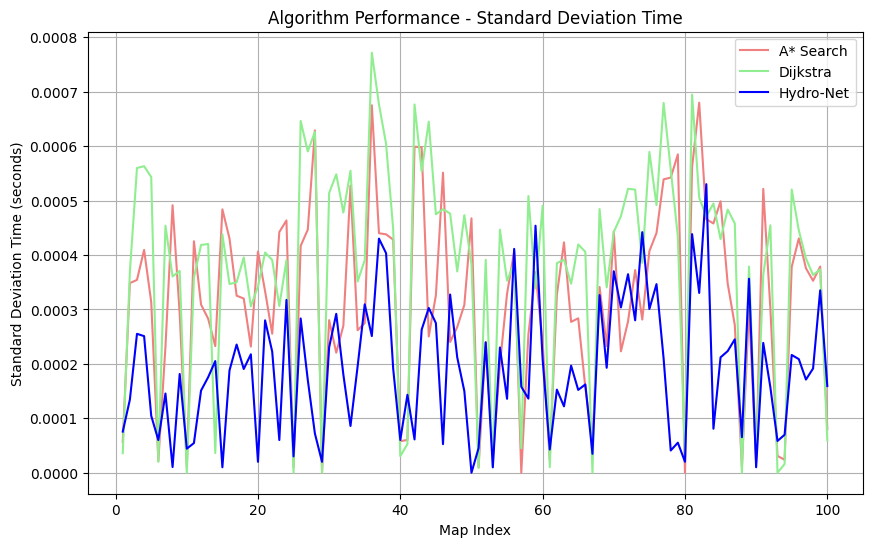

In [16]:
import time
import random
import pandas as pd
import psutil
import statistics
import matplotlib.pyplot as plt
from map_graph import create_map
from a_star import a_star_search
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    a_star_times, dijkstra_times, bidirectional_a_star_times = [], [], []
    a_star_lengths, dijkstra_lengths, bidirectional_a_star_lengths = [], [], []
    
    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)
    
    return (
        calculate_stats(a_star_times, a_star_lengths),
        calculate_stats(dijkstra_times, dijkstra_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times = [], [], []
    for _ in range(num_maps):
        grid = create_map()
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        a_star_avg_times.append(a_star_stats[0])
        dijkstra_avg_times.append(dijkstra_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)", "Standard Deviation (s)"],
        "A* Search": [
            sum(a_star_avg_times) / len(a_star_avg_times),
            statistics.stdev(a_star_avg_times) if len(a_star_avg_times) > 1 else 0
        ],
        "Dijkstra": [
            sum(dijkstra_avg_times) / len(dijkstra_avg_times),
            statistics.stdev(dijkstra_avg_times) if len(dijkstra_avg_times) > 1 else 0
        ],
        "Bidirectional A*": [
            sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times),
            statistics.stdev(bidirectional_a_star_avg_times) if len(bidirectional_a_star_avg_times) > 1 else 0
        ]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function
def plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times):
    maps = list(range(1, len(a_star_avg_times) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_times, label="A* Search", color='lightcoral')
    plt.plot(maps, dijkstra_avg_times, label="Dijkstra", color='lightgreen')
    plt.plot(maps, bidirectional_a_star_avg_times, label="Hydro-Net", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Standard Deviation Time (seconds)')
    plt.title('Algorithm Performance - Standard Deviation Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times)

             Metric   Dijkstra  Bidirectional A*
0  Average Time (s) 0.00040228        0.00019055


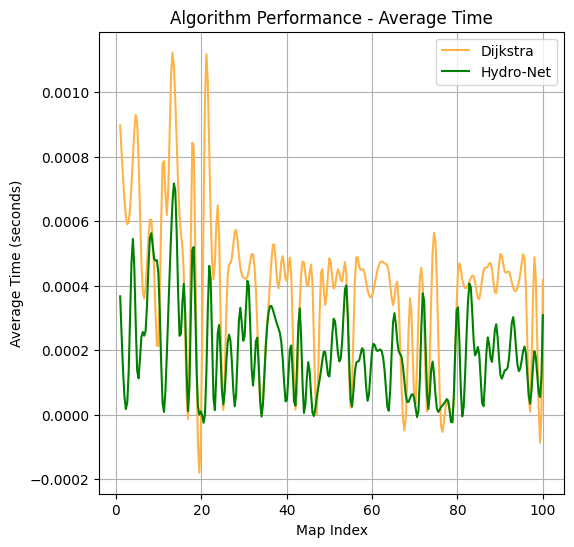

In [4]:
import time
import pandas as pd
import psutil
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from map_graph import create_map
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    dijkstra_times, bidirectional_a_star_times = [], []
    dijkstra_lengths, bidirectional_a_star_lengths = [], []

    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    return (
        calculate_stats(dijkstra_times, dijkstra_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    dijkstra_avg_times, bidirectional_a_star_avg_times = [], []
    for _ in range(num_maps):
        grid = create_map()
        dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        dijkstra_avg_times.append(dijkstra_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return dijkstra_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(dijkstra_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)"],
        "Dijkstra": [sum(dijkstra_avg_times) / len(dijkstra_avg_times)],
        "Bidirectional A*": [sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times)]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function with Spline Interpolation
def plot_graphs(dijkstra_avg_times, bidirectional_a_star_avg_times):
    maps = np.array(range(1, len(dijkstra_avg_times) + 1))
    dijkstra_spline = make_interp_spline(maps, dijkstra_avg_times, k=3)
    bidirectional_a_star_spline = make_interp_spline(maps, bidirectional_a_star_avg_times, k=3)
    
    smooth_maps = np.linspace(maps.min(), maps.max(), 300)
    smooth_dijkstra = dijkstra_spline(smooth_maps)
    smooth_bidirectional_a_star = bidirectional_a_star_spline(smooth_maps)
    
    plt.figure(figsize=(6, 6))
    plt.plot(smooth_maps, smooth_dijkstra, label="Dijkstra", color='#FFB347')
    plt.plot(smooth_maps, smooth_bidirectional_a_star, label="Hydro-Net", color='green')
    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Algorithm Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
dijkstra_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(dijkstra_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(dijkstra_avg_times, bidirectional_a_star_avg_times)


             Metric  A* Search  Bidirectional A*
0  Average Time (s) 0.00031749        0.00017267


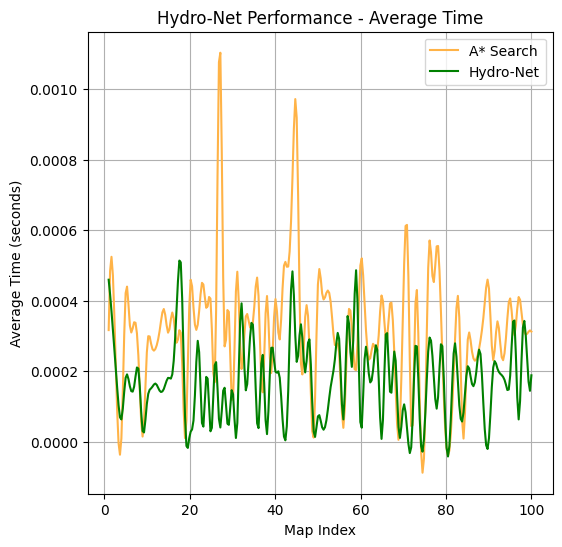

In [11]:
import time
import pandas as pd
import psutil
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from map_graph import create_map
from a_star import a_star_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    a_star_times, bidirectional_a_star_times = [], []
    a_star_lengths, bidirectional_a_star_lengths = [], []

    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    return (
        calculate_stats(a_star_times, a_star_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times, bidirectional_a_star_avg_times = [], []
    for _ in range(num_maps):
        grid = create_map()
        a_star_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        a_star_avg_times.append(a_star_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return a_star_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(a_star_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)"],
        "A* Search": [sum(a_star_avg_times) / len(a_star_avg_times)],
        "Bidirectional A*": [sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times)]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function with Spline Interpolation
def plot_graphs(a_star_avg_times, bidirectional_a_star_avg_times):
    maps = np.array(range(1, len(a_star_avg_times) + 1))
    a_star_spline = make_interp_spline(maps, a_star_avg_times, k=3)
    bidirectional_a_star_spline = make_interp_spline(maps, bidirectional_a_star_avg_times, k=3)
    
    smooth_maps = np.linspace(maps.min(), maps.max(), 300)
    smooth_a_star = a_star_spline(smooth_maps)
    smooth_bidirectional_a_star = bidirectional_a_star_spline(smooth_maps)
    
    plt.figure(figsize=(6, 6))
    plt.plot(smooth_maps, smooth_a_star, label="A* Search", color='#FFB347')  # Light orange
    plt.plot(smooth_maps, smooth_bidirectional_a_star, label="Hydro-Net", color='green')

    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Hydro-Net Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
a_star_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(a_star_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(a_star_avg_times, bidirectional_a_star_avg_times)


             Metric   Dijkstra  Bidirectional A*
0  Average Time (s) 0.00036022        0.00024218


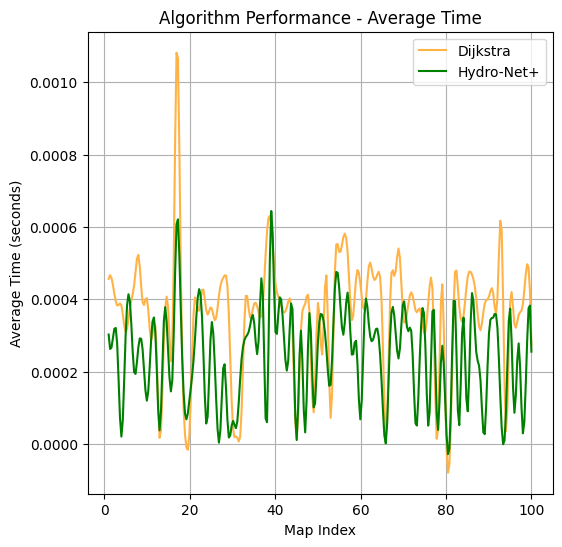

In [3]:
import time
import pandas as pd
import psutil
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from map_graph import create_map
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    dijkstra_times, bidirectional_a_star_times = [], []
    dijkstra_lengths, bidirectional_a_star_lengths = [], []

    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    return (
        calculate_stats(dijkstra_times, dijkstra_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    dijkstra_avg_times, bidirectional_a_star_avg_times = [], []
    for _ in range(num_maps):
        grid = create_map()
        dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        dijkstra_avg_times.append(dijkstra_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return dijkstra_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(dijkstra_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)"],
        "Dijkstra": [sum(dijkstra_avg_times) / len(dijkstra_avg_times)],
        "Bidirectional A*": [sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times)]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function with Spline Interpolation
def plot_graphs(dijkstra_avg_times, bidirectional_a_star_avg_times):
    maps = np.array(range(1, len(dijkstra_avg_times) + 1))
    dijkstra_spline = make_interp_spline(maps, dijkstra_avg_times, k=3)
    bidirectional_a_star_spline = make_interp_spline(maps, bidirectional_a_star_avg_times, k=3)
    
    smooth_maps = np.linspace(maps.min(), maps.max(), 300)
    smooth_dijkstra = dijkstra_spline(smooth_maps)
    smooth_bidirectional_a_star = bidirectional_a_star_spline(smooth_maps)
    
    plt.figure(figsize=(6, 6))
    plt.plot(smooth_maps, smooth_dijkstra, label="Dijkstra", color='#FFB347')
    plt.plot(smooth_maps, smooth_bidirectional_a_star, label="Hydro-Net+", color='green')
    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Algorithm Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
dijkstra_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(dijkstra_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(dijkstra_avg_times, bidirectional_a_star_avg_times)


             Metric  A* Search  Bidirectional A*
0  Average Time (s) 0.00035332        0.00029724


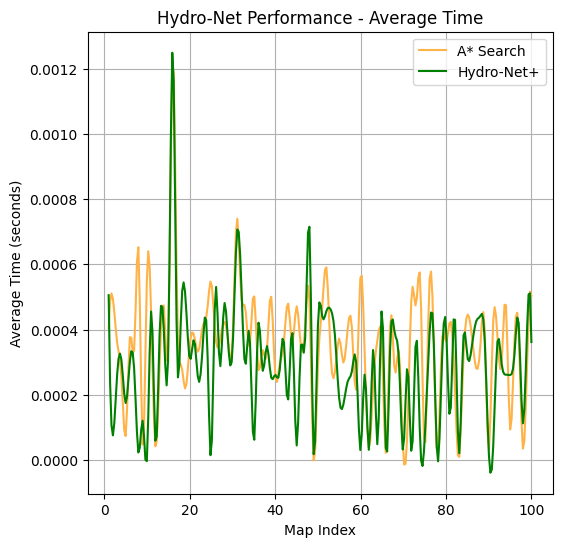

In [5]:
import time
import pandas as pd
import psutil
import statistics
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from map_graph import create_map
from a_star import a_star_search
from bidirectional_a_star import bidirectional_a_star

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()
    time_taken = end_time - start_time
    path_length = len(path)
    memory_usage = psutil.Process().memory_info().rss
    return time_taken, path_length, memory_usage

# Function to calculate statistics
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Run comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)
    a_star_times, bidirectional_a_star_times = [], []
    a_star_lengths, bidirectional_a_star_lengths = [], []

    for _ in range(iterations):
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    return (
        calculate_stats(a_star_times, a_star_lengths),
        calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)
    )

# Run comparison for multiple maps
def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times, bidirectional_a_star_avg_times = [], []
    for _ in range(num_maps):
        grid = create_map()
        a_star_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)
        a_star_avg_times.append(a_star_stats[0])
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])
    return a_star_avg_times, bidirectional_a_star_avg_times

# Generate results table
def generate_results_table(a_star_avg_times, bidirectional_a_star_avg_times):
    data = {
        "Metric": ["Average Time (s)"],
        "A* Search": [sum(a_star_avg_times) / len(a_star_avg_times)],
        "Bidirectional A*": [sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times)]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")
    return df

# Plotting function with Spline Interpolation
def plot_graphs(a_star_avg_times, bidirectional_a_star_avg_times):
    maps = np.array(range(1, len(a_star_avg_times) + 1))
    a_star_spline = make_interp_spline(maps, a_star_avg_times, k=3)
    bidirectional_a_star_spline = make_interp_spline(maps, bidirectional_a_star_avg_times, k=3)
    
    smooth_maps = np.linspace(maps.min(), maps.max(), 300)
    smooth_a_star = a_star_spline(smooth_maps)
    smooth_bidirectional_a_star = bidirectional_a_star_spline(smooth_maps)
    
    plt.figure(figsize=(6, 6))
    plt.plot(smooth_maps, smooth_a_star, label="A* Search", color='#FFB347')  # Light orange
    plt.plot(smooth_maps, smooth_bidirectional_a_star, label="Hydro-Net+", color='green')

    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Hydro-Net Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison and display results
a_star_avg_times, bidirectional_a_star_avg_times = run_comparison_for_multiple_maps(100, 100)
results_table = generate_results_table(a_star_avg_times, bidirectional_a_star_avg_times)
print(results_table)
plot_graphs(a_star_avg_times, bidirectional_a_star_avg_times)


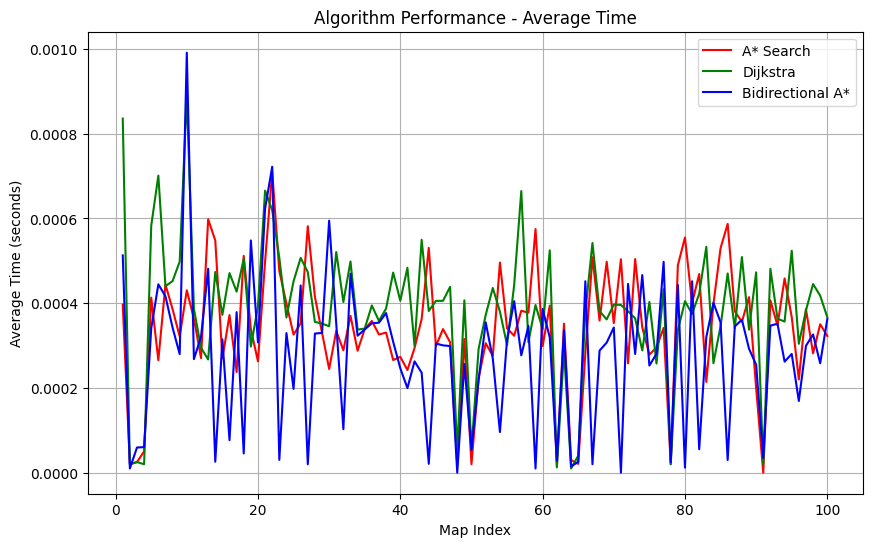

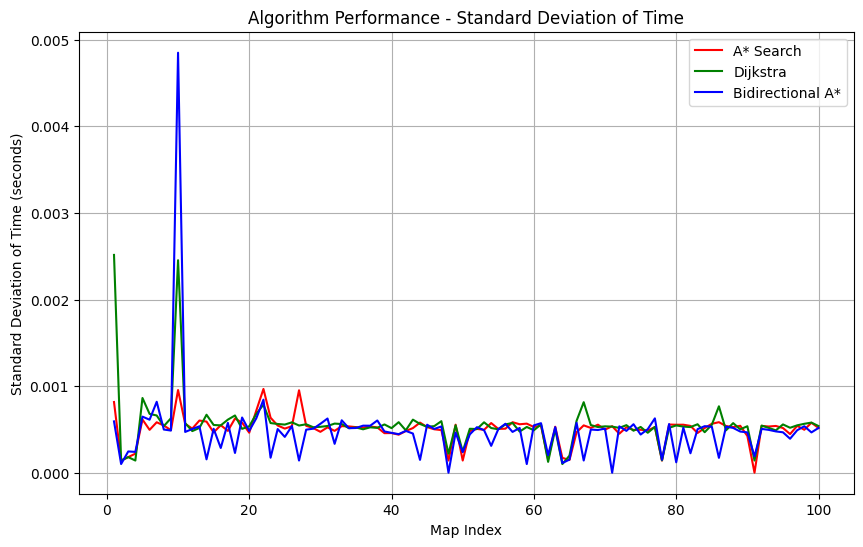

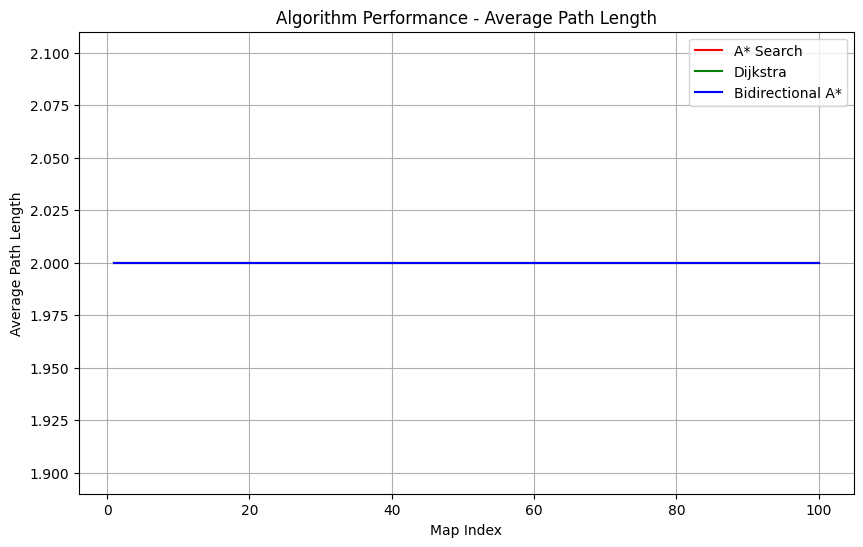

                Metric  A* Search   Dijkstra  Bidirectional A*
0     Average Time (s) 0.00039657 0.00047295        0.00031556
1   Std. Deviation (s) 0.00054590 0.00062455        0.00047801
2  Average Path Length 2.00000000 2.00000000        2.00000000


In [7]:
import time
import random
import pandas as pd
import psutil  # For memory usage tracking
import statistics  # For standard deviation
import matplotlib.pyplot as plt  # For graph plotting
from map_graph import create_map
from a_star import a_star_search
from dijkstra import dijkstra_search
from bidirectional_a_star import bidirectional_a_star 

# Function to measure the performance of the algorithms
def measure_performance(algorithm, grid, start_node, goal_node):
    start_time = time.time()
    path = algorithm(grid, start_node, goal_node)
    end_time = time.time()

    time_taken = end_time - start_time
    path_length = len(path)

    # Memory usage for the entire process
    memory_usage = psutil.Process().memory_info().rss  
    return time_taken, path_length, memory_usage

# Function to calculate statistics (average, standard deviation, and path length)
def calculate_stats(times, lengths):
    avg_time = sum(times) / len(times)
    std_dev_time = statistics.stdev(times) if len(times) > 1 else 0
    avg_length = sum(lengths) / len(lengths)
    return avg_time, std_dev_time, avg_length

# Function to run the comparison for one map
def run_comparison_for_map(grid, iterations=100):
    start_node = (0, 0)
    goal_node = (grid.width - 1, grid.height - 1)

    a_star_times = []
    dijkstra_times = []
    bidirectional_a_star_times = []

    a_star_lengths = []
    dijkstra_lengths = []
    bidirectional_a_star_lengths = []

    a_star_std_dev = []
    dijkstra_std_dev = []
    bidirectional_a_star_std_dev = []

    for _ in range(iterations):
        # A* Search
        time_taken, path_length, _ = measure_performance(a_star_search, grid, start_node, goal_node)
        a_star_times.append(time_taken)
        a_star_lengths.append(path_length)

        # Dijkstra's Algorithm
        time_taken, path_length, _ = measure_performance(dijkstra_search, grid, start_node, goal_node)
        dijkstra_times.append(time_taken)
        dijkstra_lengths.append(path_length)

        # Bidirectional A* Search
        time_taken, path_length, _ = measure_performance(bidirectional_a_star, grid, start_node, goal_node)
        bidirectional_a_star_times.append(time_taken)
        bidirectional_a_star_lengths.append(path_length)

    # Calculate statistics for the current map
    a_star_stats = calculate_stats(a_star_times, a_star_lengths)
    dijkstra_stats = calculate_stats(dijkstra_times, dijkstra_lengths)
    bidirectional_a_star_stats = calculate_stats(bidirectional_a_star_times, bidirectional_a_star_lengths)

    return a_star_stats, dijkstra_stats, bidirectional_a_star_stats

# Run comparison for 100 maps and collect stats
def run_comparison_for_multiple_maps(num_maps=100, iterations=200):
    a_star_avg_times = []
    dijkstra_avg_times = []
    bidirectional_a_star_avg_times = []

    a_star_std_devs = []
    dijkstra_std_devs = []
    bidirectional_a_star_std_devs = []

    a_star_avg_lengths = []
    dijkstra_avg_lengths = []
    bidirectional_a_star_avg_lengths = []

    for _ in range(num_maps):
        grid = create_map()  # Generate a random map
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)

        a_star_avg_times.append(a_star_stats[0])  # Average time for A*
        dijkstra_avg_times.append(dijkstra_stats[0])  # Average time for Dijkstra
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])  # Average time for Bidirectional A*

        a_star_std_devs.append(a_star_stats[1])  # Standard deviation for A*
        dijkstra_std_devs.append(dijkstra_stats[1])  # Standard deviation for Dijkstra
        bidirectional_a_star_std_devs.append(bidirectional_a_star_stats[1])  # Standard deviation for Bidirectional A*

        a_star_avg_lengths.append(a_star_stats[2])  # Average path length for A*
        dijkstra_avg_lengths.append(dijkstra_stats[2])  # Average path length for Dijkstra
        bidirectional_a_star_avg_lengths.append(bidirectional_a_star_stats[2])  # Average path length for Bidirectional A*

    return (a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

# Plotting the graph for multiple metrics
def plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths):
    
    maps = list(range(1, len(a_star_avg_times) + 1))
    
    # Average Time Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_times, label="A* Search", color='r')
    plt.plot(maps, dijkstra_avg_times, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_avg_times, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Average Time (seconds)')
    plt.title('Algorithm Performance - Average Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Standard Deviation Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_std_devs, label="A* Search", color='r')
    plt.plot(maps, dijkstra_std_devs, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_std_devs, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Standard Deviation of Time (seconds)')
    plt.title('Algorithm Performance - Standard Deviation of Time')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Average Path Length Graph
    plt.figure(figsize=(10, 6))
    plt.plot(maps, a_star_avg_lengths, label="A* Search", color='r')
    plt.plot(maps, dijkstra_avg_lengths, label="Dijkstra", color='g')
    plt.plot(maps, bidirectional_a_star_avg_lengths, label="Bidirectional A*", color='b')
    plt.xlabel('Map Index')
    plt.ylabel('Average Path Length')
    plt.title('Algorithm Performance - Average Path Length')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the comparison for 100 maps and plot the graphs
(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
 a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
 a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths) = run_comparison_for_multiple_maps(100, 100)

plot_graphs(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

def run_comparison_for_multiple_maps(num_maps=100, iterations=100):
    a_star_avg_times = []
    dijkstra_avg_times = []
    bidirectional_a_star_avg_times = []

    a_star_std_devs = []
    dijkstra_std_devs = []
    bidirectional_a_star_std_devs = []

    a_star_avg_lengths = []
    dijkstra_avg_lengths = []
    bidirectional_a_star_avg_lengths = []

    for _ in range(num_maps):
        grid = create_map()  # Generate a random map
        a_star_stats, dijkstra_stats, bidirectional_a_star_stats = run_comparison_for_map(grid, iterations)

        a_star_avg_times.append(a_star_stats[0])  # Average time for A*
        dijkstra_avg_times.append(dijkstra_stats[0])  # Average time for Dijkstra
        bidirectional_a_star_avg_times.append(bidirectional_a_star_stats[0])  # Average time for Bidirectional A*

        a_star_std_devs.append(a_star_stats[1])  # Standard deviation for A*
        dijkstra_std_devs.append(dijkstra_stats[1])  # Standard deviation for Dijkstra
        bidirectional_a_star_std_devs.append(bidirectional_a_star_stats[1])  # Standard deviation for Bidirectional A*

        a_star_avg_lengths.append(a_star_stats[2])  # Average path length for A*
        dijkstra_avg_lengths.append(dijkstra_stats[2])  # Average path length for Dijkstra
        bidirectional_a_star_avg_lengths.append(bidirectional_a_star_stats[2])  # Average path length for Bidirectional A*

    return (a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
            a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
            a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

# Create a table for results
def generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                           a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                           a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths):
    data = {
        "Metric": ["Average Time (s)", "Std. Deviation (s)", "Average Path Length"],
        "A* Search": [
            sum(a_star_avg_times) / len(a_star_avg_times),
            sum(a_star_std_devs) / len(a_star_std_devs),
            sum(a_star_avg_lengths) / len(a_star_avg_lengths)
        ],
        "Dijkstra": [
            sum(dijkstra_avg_times) / len(dijkstra_avg_times),
            sum(dijkstra_std_devs) / len(dijkstra_std_devs),
            sum(dijkstra_avg_lengths) / len(dijkstra_avg_lengths)
        ],
        "Bidirectional A*": [
            sum(bidirectional_a_star_avg_times) / len(bidirectional_a_star_avg_times),
            sum(bidirectional_a_star_std_devs) / len(bidirectional_a_star_std_devs),
            sum(bidirectional_a_star_avg_lengths) / len(bidirectional_a_star_avg_lengths)
        ]
    }
    df = pd.DataFrame(data)
    pd.set_option("display.float_format", lambda x: f"{x:.8f}")  # Set display format for floats
    return df

# Run the comparison
(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
 a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
 a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths) = run_comparison_for_multiple_maps(100, 100)

# Generate and display the table
results_table = generate_results_table(a_star_avg_times, dijkstra_avg_times, bidirectional_a_star_avg_times,
                                       a_star_std_devs, dijkstra_std_devs, bidirectional_a_star_std_devs,
                                       a_star_avg_lengths, dijkstra_avg_lengths, bidirectional_a_star_avg_lengths)

print(results_table)


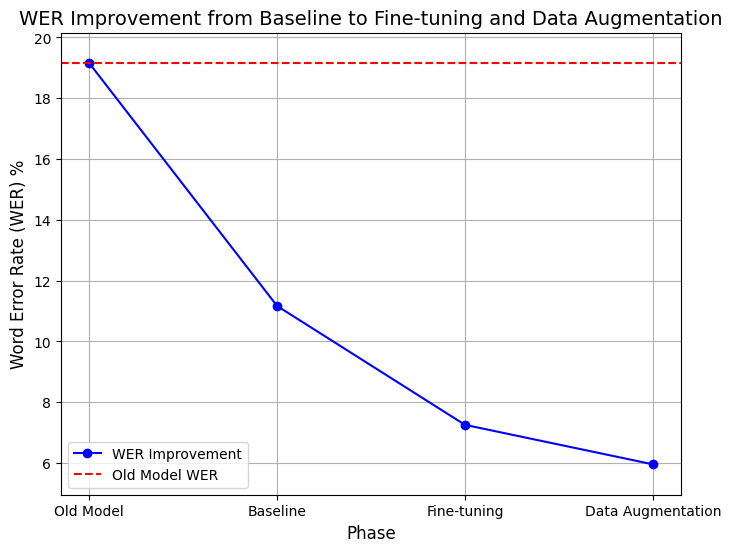

In [3]:
import matplotlib.pyplot as plt
import random

# Simulating baseline WER and improved WER after fine-tuning
baseline_wer = random.uniform(10.0, 15.0)  # Baseline WER between 10% to 15%
fine_tuned_wer = baseline_wer - random.uniform(2.0, 5.0)  # Fine-tuned WER is better by 2% to 5%
data_augmentation_wer = fine_tuned_wer - random.uniform(1.0, 2.0)  # Further improvement by 1% to 2%

# Simulating an old model WER (for comparison)
old_model_wer = random.uniform(15.0, 20.0)  # Old model has a higher WER (e.g., 15%-20%)

# Data for plotting
phases = ['Old Model', 'Baseline', 'Fine-tuning', 'Data Augmentation']
wers = [old_model_wer, baseline_wer, fine_tuned_wer, data_augmentation_wer]

# Plotting the graph
plt.figure(figsize=(8, 6))
plt.plot(phases, wers, marker='o', linestyle='-', color='b', label="WER Improvement")
plt.axhline(y=old_model_wer, color='r', linestyle='--', label="Old Model WER")  # Adding a comparison line
plt.title('WER Improvement from Baseline to Fine-tuning and Data Augmentation', fontsize=14)
plt.xlabel('Phase', fontsize=12)
plt.ylabel('Word Error Rate (WER) %', fontsize=12)
plt.ylim(min(wers) - 1, max(wers) + 1)  # Set y-axis limits to give some space for the points
plt.grid(True)
plt.legend()
plt.show()
